# Tower of Hanoi

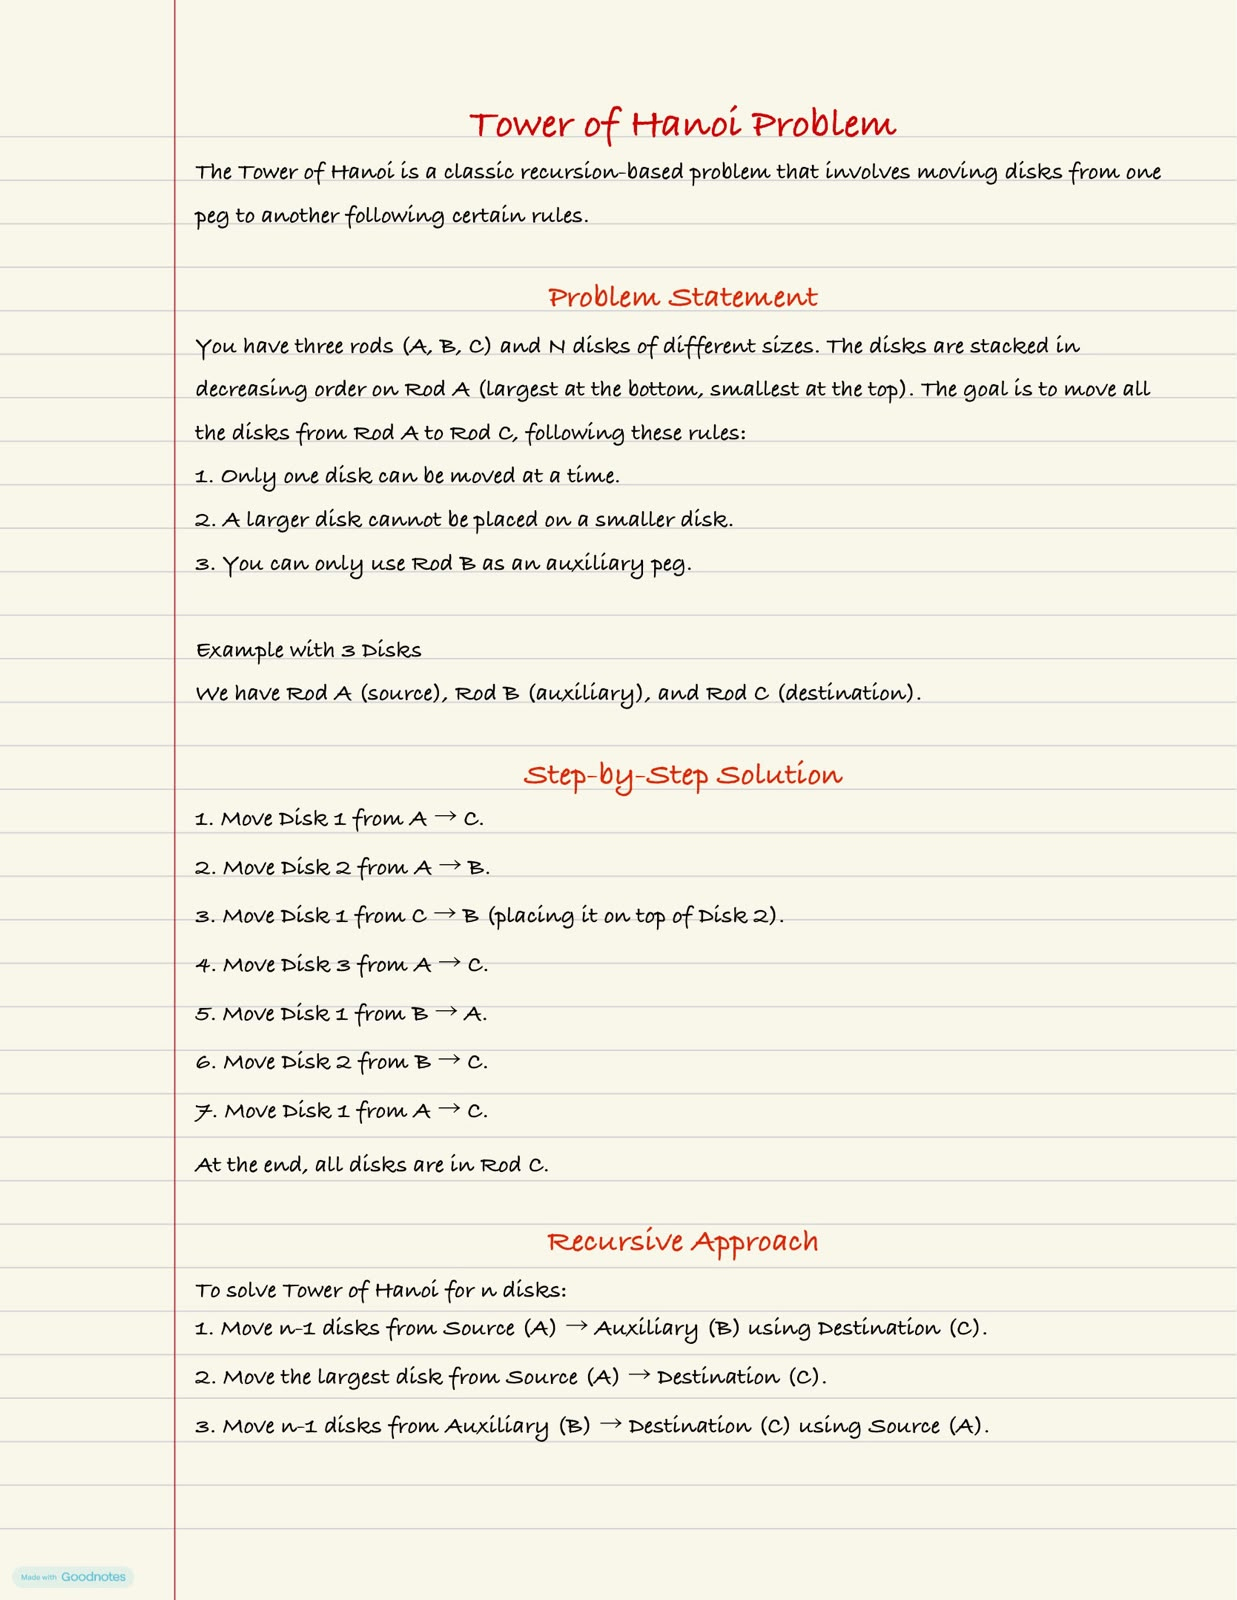

Our goal is to move all of the discs from tower A to tower C given the following
constraints:

a) Only one disc can be moved at a time.

b) The topmost disc of any tower is the only one available for moving.

c) A wider disc can never be atop a narrower disc.

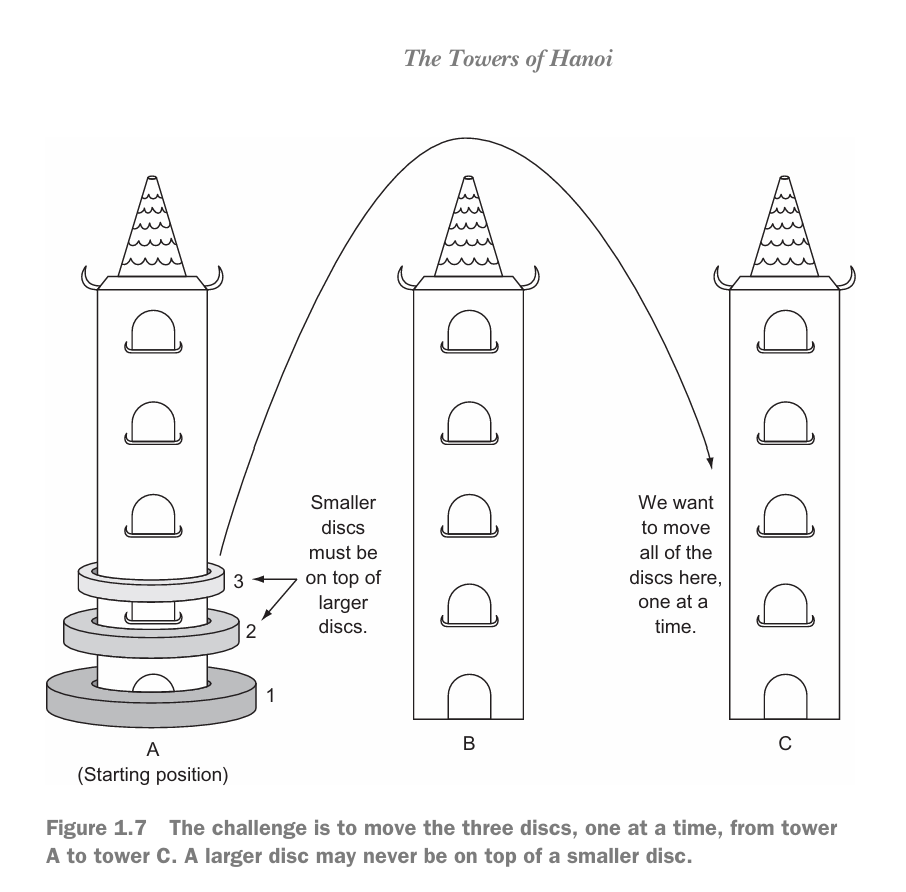

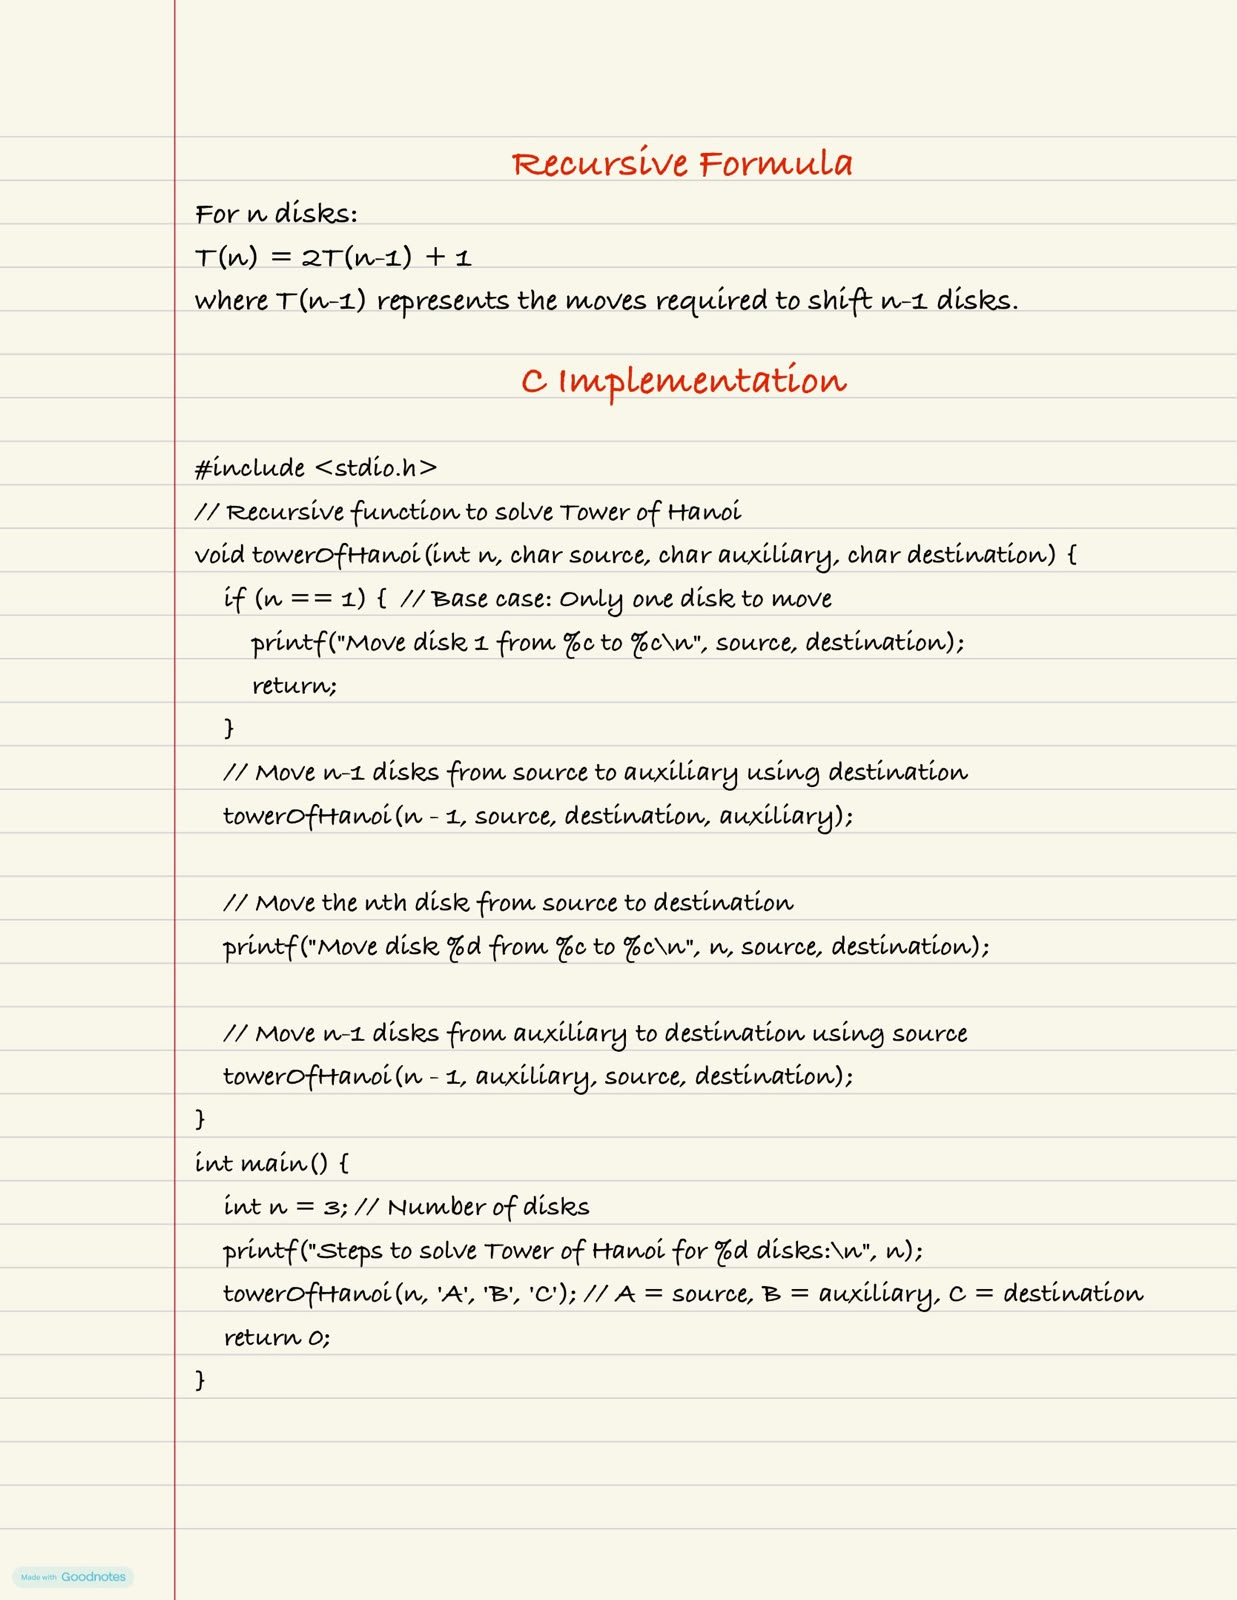

In [1]:
from typing import TypeVar, Generic, List

## List
List is used to specify the type of elements inside a list.

In [2]:
from typing import List

numbers: List[int] = [1, 2, 3, 4]
names: List[str] = ["Prince", "Rahul", "Amit"]

## TypeVar
TypeVar means Type Variable.
It allows you to create a placeholder for a type.

In [3]:
from typing import TypeVar

T = TypeVar("T")

Here, T is not an actual data type like int or str.

It represents a type that will be specified later.

In [4]:
T = TypeVar("T")

def first_item(items: list[T]) -> T:
    return items[0]

The type of the returned value corresponds to the type of the list elements.

Simple meaning: T acts as a placeholder for a type.

In [5]:
print(first_item([1, 2, 3]))       # 1
print(first_item(["A", "B"]))     # A

1
A


## Generic
Generic is used to create classes that can work with different data types while preserving type information.

The same Stack class can work with multiple data types.

Stack[int]  -> Stores integers

Stack[str]  -> Stores strings

Stack[float] -> Stores floats

In [6]:
from typing import List, TypeVar, Generic

T = TypeVar('T')

class Stack(Generic[T]):

    def __init__(self) -> None:
        self._container: List[T] = []

    def push(self, item: T) -> None:
        self._container.append(item)

    def pop(self) -> T:
        return self._container.pop()

    def __repr__(self) -> str:
        return repr(self._container)

    

Say we have three
discs (top, middle, and bottom) on tower A that we want to move to tower C. 

first move the top disc to tower C. 

Then move the middle disc to tower B. 

Then move the top disc from tower C to tower B. 

Now we have the bottom disc still on tower A and
the upper two discs on tower B. Essentially, we have now successfully moved two discs
from one tower (A) to another tower (B). Moving the bottom disc from A to C is our
base case (moving a single disc). Now we can move the two upper discs from B to C in
the same procedure that we did from A to B. We move the top disc to A, the middle
disc to C, and finally the top disc from A to C.

1 Move the upper n-1 discs from tower A (SOURCE) to B (AUXILIARY/temporary), using C (DESTINATION) as
the in-between.

2 Move the single lowest disc from A (SOURCE) to C (DESTINATION).

3 Move the n-1 discs from tower B (AUXILIARY/temporary) to C (DESTINATION), using A (SOURCE) as the in-between.

In [7]:
def hanoi(n: int, source: Stack[int], auxiliary: Stack[int], destination: Stack[int]):
    if n == 1:
        destination.push(source.pop())

    else:
        hanoi(n-1, source, destination, auxiliary)
        hanoi(1, source, auxiliary, destination)
        hanoi(n-1, auxiliary, source, destination)
    
    

In [8]:
if __name__ == "__main__":

    numDiscs: int = 18
    towerA: Stack[int] = Stack()
    towerB: Stack[int] = Stack()
    towerC: Stack[int] = Stack()

    for i in range(numDiscs, 0, -1):
        towerA.push(i)

    print("\n-----Before------")

    print("Tower A: {}".format(towerA))
    print("Tower B: {}".format(towerB))
    print("Tower C: {}".format(towerC))

    print("\n------After------")
    hanoi(numDiscs, towerA, towerB, towerC)
    print("Tower A: {}".format(towerA))
    print("Tower B: {}".format(towerB))
    print("Tower C: {}".format(towerC))


-----Before------
Tower A: [18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
Tower B: []
Tower C: []

------After------
Tower A: []
Tower B: []
Tower C: [18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
